Plot Figure 1a, 1b, 1d
--

In [3]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Circle
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D

from config import IUMFIGDIR
from IUM.read_data.read_data import load_raw_ctrl_surf_var, load_raw_pert_surf_var
from IUM.plots.p_config import var_names, cmaps, clim_vars, figsize

In [16]:
### CST ###

vars = {'t2': {'unit': '$^\circ$C', 'flab': 'f'},
        'q2': {'unit': 'g kg$^{-1}$', 'flab': 'i'},
        'PBLh': {'unit': 'm', 'flab': 'o'}}

res = 0.5
value = 0.3
value_pert = 1.
length = 50
u = 4.
env = 'stable'
date = '10010101'
time = 15
window = 3


>>> t2 <<<
30.0 33.0

>>> q2 <<<
14.0 20.0

>>> PBLh <<<
257.0 1055.0


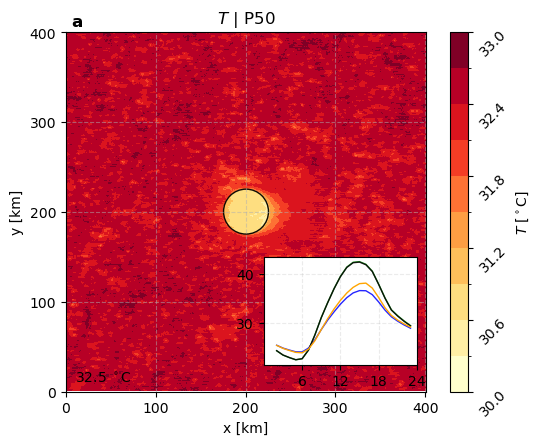

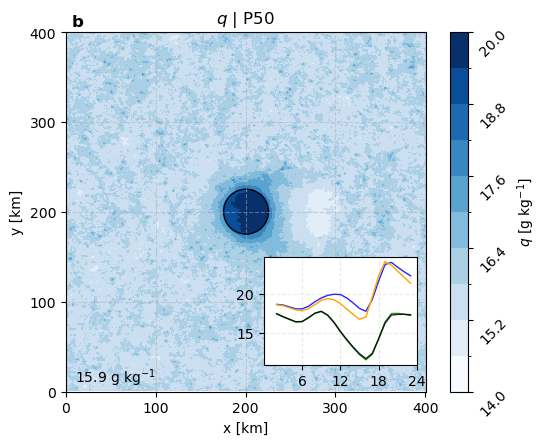

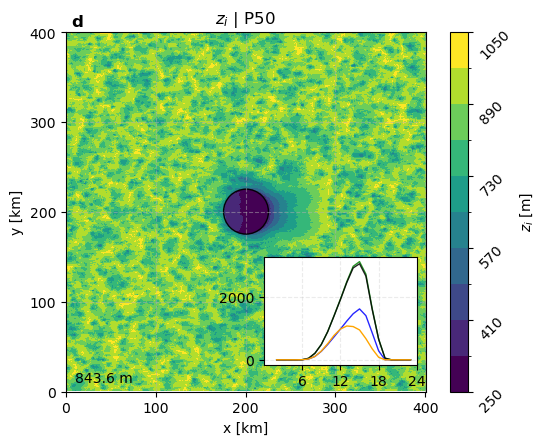

In [18]:
xs = np.arange(res, 400.+res, res)
ys = xs
xc = (xs[-1] - xs[0]) / 2 + res / 2
yc = (ys[-1] - ys[0]) / 2 + res / 2

xsm, ysm = np.meshgrid(xs, ys)

r = length / 2

distloc = ( ((xsm - xc) * (xsm - xc)) + ((ysm - yc) * (ysm - yc)) )**.5

xtcks = np.arange(0, 400+100, 100)
ytcks = xtcks

xtcks2 = np.arange(6, 24+6, 6)
xtlbs2 = xtcks2

for var, kws in vars.items():
    print('\n>>> %s <<<'%var)

    data_udry = load_raw_ctrl_surf_var(res=res, value=value, u=u, env=env, date=date, variable=var)
    data_uwet = load_raw_ctrl_surf_var(res=res, value=value_pert, u=u, env=env, date=date, variable=var)
    data = load_raw_pert_surf_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable=var)

    if var == 't2':
        data_udry = data_udry - 273.15
        data_uwet = data_uwet - 273.15
        data = data - 273.15
        flab0 = 'a'
        flab1 = 'b'
    elif var == 'q2':
        data_udry = data_udry * 1000
        data_uwet = data_uwet * 1000
        data = data * 1000
        flab0 = 'b'
        flab1 = 'd'
    elif var == 'PBLh':
        data_udry = data_udry  # .isel(T1HR_MN=slice(7,19))
        data_uwet = data_uwet  # .isel(T1HR_MN=slice(7,19))
        data = data  # .isel(T1HR_MN=slice(7,19))
        flab0 = 'd'
        flab1 = 'h'

    if var in ['t2', 'q2']:
        data_udry_rm = data_udry.rolling(T1HR_MN=window, center=True).mean()
        data_uwet_rm = data_uwet.rolling(T1HR_MN=window, center=True).mean()
        data_rm = data.rolling(T1HR_MN=window, center=True).mean()
    elif var in ['sh', 'lh']:
        data_rm = data.rolling(T1HR_MN=window, center=True).mean()
    elif var == 'PBLh':
        data_udry_rm = data_udry.rolling(T1HR_MN=window, center=True).mean()
        data_uwet_rm = data_uwet.rolling(T1HR_MN=window, center=True).mean()
        data_rm = data.rolling(T1HR_MN=window, center=True).mean()

    coords = data.coords
    tcoord = [coord for coord in coords if 'T1HR' in coord]

    disc_mask = np.broadcast_to(distloc <= r, data_rm.shape)   # True in disc

    spacemean_udry = data_udry_rm.mean(dim=['latitude_t', 'longitude_t'])
    spacemean_uwet = data_uwet_rm.mean(dim=['latitude_t', 'longitude_t'])
    spacemean = data_rm.mean(dim=['latitude_t', 'longitude_t'])

    datawet = data_rm.where(disc_mask)
    datawet_spacemean = datawet.mean(dim=['latitude_t', 'longitude_t'])

    timemean_wet = datawet_spacemean.mean(dim=tcoord)

    varname = var_names[var]
    cmap = cmaps[var]
    unit = kws['unit']
    flab = kws['flab']

    coords = data.coords
    tcoord = [coord for coord in coords if 'T1HR' in coord]

    timemean = data_rm.mean(dim=tcoord)
    mean = timemean.mean().values
    varmin = np.floor(timemean.min().values)
    varmax = np.ceil(timemean.max().values)
    print(varmin, varmax)

    cmap = plt.get_cmap(cmap)

    clim = clim_vars[var]
    clim_min = clim[0]
    clim_max = clim[1]
    bounds = np.linspace(clim_min, clim_max, 11)
    norm = BoundaryNorm(bounds, cmap.N)  #, extend='both')

    circle = Circle((xs[int(len(xs)/2)], ys[int(len(ys)/2)]), r, facecolor='none', edgecolor='k', linewidth=1, alpha=0.95)

    ts = np.arange(len(spacemean)) + 1


    fig, ax0 = plt.subplots()

    plt.subplots_adjust(bottom=0.125, top=0.925, left=0.1, wspace=0.01)

    p = timemean.plot(ax=ax0, norm=norm, cmap=cmap, add_colorbar=False)

    ax0.text(0.025, 0.025, '%.1f %s'%(mean, unit), transform=ax0.transAxes)
    ax0.text(0.015, 1.015, flab0, weight='bold', fontsize=12, transform=ax0.transAxes)

    ax0.add_patch(circle)
    ax1 = ax0.inset_axes([0.55, 0.075, 0.425, 0.3])

    ax1.plot(ts, spacemean_udry.values, color='g', lw=1., alpha=0.85, label='UDRY')
    ax1.plot(ts, spacemean_uwet.values, color='b', lw=1., alpha=0.85, label='UWET')
    ax1.plot(ts, spacemean.values, color='k', lw=1., alpha=0.85, label='P%i(all)'%length)
    ax1.plot(ts, datawet_spacemean.values, lw=1., color='orange', label='P%i(patch)'%length)

    ax0.set_aspect('equal')
    ax0.set_xticks(xtcks)
    ax0.set_xlabel('x [km]')
    ax0.set_yticks(ytcks)
    ax0.set_ylabel('y [km]')
    ax0.grid(True, alpha=0.5, ls='--')
    ax0.set_title('%s | P%i'%(varname, length))

    ax1.set_xticks(xtcks2)
    ax1.set_xticklabels(xtlbs2)
    ax1.set_xlim(0, 24)
    ax1.grid(True, ls='--', alpha=0.25)

    cb = plt.colorbar(p, norm=norm, cmap=cmap, ax=ax0, orientation='vertical', label='%s [%s]'%(varname, unit), pad=0.05)
    cb.ax.tick_params(rotation=45)

    fig.set_size_inches(6., 4.5)
